# Monitoring & Learning Agent

## Objective

The Monitoring Agent evaluates the effectiveness of the dynamic pricing strategy.

It compares charging station performance before and after tariff adjustments and determines whether the pricing policy should be retained or revised.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
merged = pd.read_csv(
    "final_merged_dataset.csv"
)

merged.head()

,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018


In [43]:
def recommend_price(
    occupancy,
    current_price
):

    if occupancy >= high_occ:
        return current_price * 1.15

    elif occupancy >= medium_occ:
        return current_price * 1.10

    elif occupancy <= low_occ:
        return current_price * 0.85

    return current_price

In [44]:
high_occ = merged["occupancy"].quantile(0.80)
medium_occ = merged["occupancy"].quantile(0.60)
low_occ = merged["occupancy"].quantile(0.20)

print("High:", high_occ)
print("Medium:", medium_occ)
print("Low:", low_occ)

High: 25.85182186234818
Medium: 23.364372469635622
Low: 18.26315789473684


In [45]:
merged["recommended_price"] = merged.apply(
    lambda row:
    recommend_price(
        row["occupancy"],
        row["price"]
    ),
    axis=1
)

## Revenue Evaluation

Revenue is calculated before and after dynamic pricing.

Revenue = Demand × Price

The resulting comparison measures the financial impact of the tariff strategy.

In [46]:
merged["old_revenue"] = (
    merged["price"]
    *
    merged["demand"]
)

merged["new_revenue"] = (
    merged["recommended_price"]
    *
    merged["demand"]
)

## Utilization Monitoring

Charging intervals are classified into:

- High Utilization
- Medium Utilization
- Low Utilization

This classification helps monitor how frequently pricing adjustments are triggered.

In [47]:
def utilization_zone(x):

    if x >= 27:
        return "High"

    elif x <= 18:
        return "Low"

    return "Medium"

In [48]:
merged["utilization_zone"] = (
    merged["occupancy"]
    .apply(utilization_zone)
)

merged["utilization_zone"].value_counts()

utilization_zone
Medium    6697
Low       1450
High       492
Name: count, dtype: int64

## Pricing Success Analysis

Pricing success is defined as:

Revenue Change > 0

A successful pricing decision generates more revenue than the original tariff.

In [49]:
merged["revenue_change"] = (
    merged["new_revenue"]
    -
    merged["old_revenue"]
)

merged["pricing_success"] = (
    merged["revenue_change"] > 0
).astype(int)

merged[
    [
        "revenue_change",
        "pricing_success"
    ]
].head()

,revenue_change,pricing_success
0,3.508759,1
1,3.652573,1
2,4.058046,1
3,4.231739,1
4,4.362295,1


In [50]:
success_rate = (
    merged["pricing_success"]
    .mean()
    * 100
)

print(
    f"Pricing Success Rate: {success_rate:.2f}%"
)

Pricing Success Rate: 40.03%


### Pricing Performance

The dynamic pricing strategy achieved a Pricing Success Rate of 40.03%.

This indicates that approximately 40% of charging intervals generated higher revenue under dynamic pricing.

In [51]:
old_rev = merged["old_revenue"].sum()

new_rev = merged["new_revenue"].sum()

print(
    f"Old Revenue: {old_rev:.2f}"
)

print(
    f"New Revenue: {new_rev:.2f}"
)

gain = (
    (new_rev - old_rev)
    /
    old_rev
) * 100

print(
    f"Revenue Gain: {gain:.2f}%"
)

Old Revenue: 300645.39
New Revenue: 313298.26
Revenue Gain: 4.21%


In [52]:
old_rev = merged["old_revenue"].sum()

new_rev = merged["new_revenue"].sum()

print(
    f"Old Revenue: {old_rev:.2f}"
)

print(
    f"New Revenue: {new_rev:.2f}"
)

gain = (
    (new_rev - old_rev)
    /
    old_rev
) * 100

print(
    f"Revenue Gain: {gain:.2f}%"
)

Old Revenue: 300645.39
New Revenue: 313298.26
Revenue Gain: 4.21%


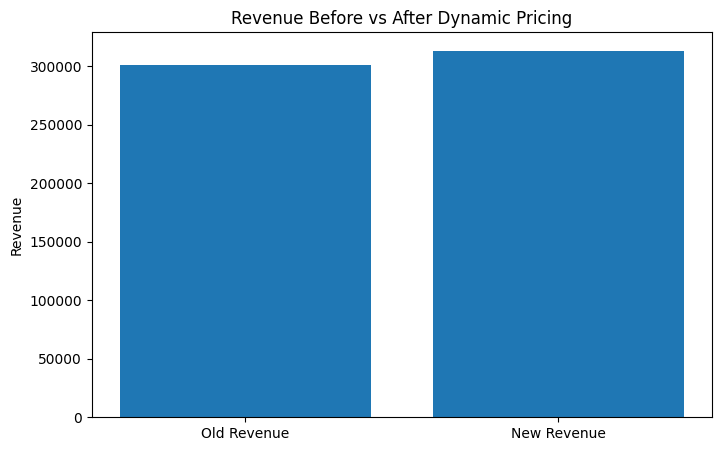

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Old Revenue", "New Revenue"],
    [old_rev, new_rev]
)

plt.title(
    "Revenue Before vs After Dynamic Pricing"
)

plt.ylabel("Revenue")

plt.show()

### Revenue Comparison

Total revenue increased from ₹300,645 to ₹313,298.

This represents a revenue improvement of 4.21%, demonstrating the effectiveness of utilization-based pricing.

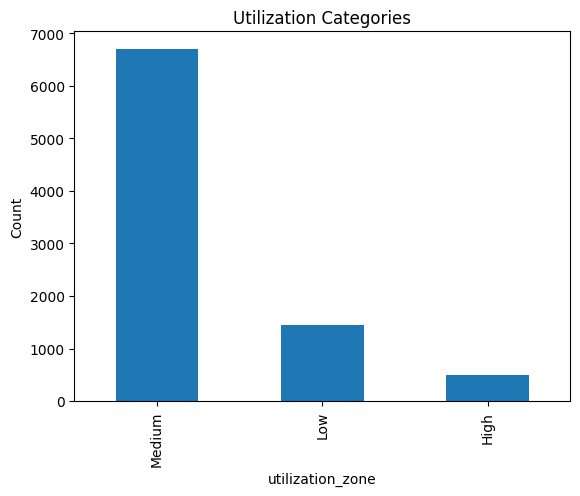

In [54]:
merged[
    "utilization_zone"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Utilization Categories"
)

plt.ylabel(
    "Count"
)

plt.show()

In [55]:
avg_gain = (
    merged["revenue_change"]
    .mean()
)

print(
    f"Average Revenue Change: {avg_gain:.2f}"
)

Average Revenue Change: 1.46


In [57]:
if avg_gain > 0:

    pricing_decision = (
        "Current pricing strategy retained"
    )

else:

    pricing_decision = (
        "Pricing strategy should be revised"
    )

print(pricing_decision)

Current pricing strategy retained


In [58]:
merged.to_csv(
    "monitoring_results.csv",
    index=False
)

print(
    "Saved monitoring_results.csv"
)

Saved monitoring_results.csv
